# **Ejercicios 8, 9 y 10 — Análisis de sentimiento y negatividad**

## **Enfoque**

Para el ejercicio 8 se necesita una función que reciba un tweet y determine qué tan positivo,
negativo o neutro es a partir de sus palabras. Se usa **VADER** (`vaderSentiment`) en lugar de
`TextBlob`, porque su léxico y sus reglas están construidos específicamente para texto de redes
sociales: pondera mayúsculas, signos de puntuación repetidos, negaciones ("not good") e
intensificadores ("very good"), que es justo el tipo de señal que un léxico genérico como el de
TextBlob ignora.

La función corre sobre `texto_sentimiento` y no sobre `tokens`, porque esa columna conserva
mayúsculas, puntuación y negaciones (ver `src/texto.py`, `normalizar_para_sentimiento`), que son
exactamente las señales que lee VADER. Si se usara la versión agresiva de limpieza, un texto donde
ya se quitó "not" como stopword se puntuaría con el sentido invertido.

Sobre la pregunta de si vale la pena dejar los emoticones: en `src/decisiones.md` ya se midió que
los emoticones ASCII aparecen en menos del 1% de los tweets y que no hay ni un solo emoji unicode
en el dataset, así que no habría forma de que movieran el resultado. No se hizo tratamiento especial
para ellos.

La misma lógica de esta función corre como etapa 9 del pipeline (`src/09_sentimiento.py`), que ya
dejó las columnas de sentimiento pegadas a `train_modelado.csv` y `test_modelado.csv`. Acá se
redefine la función para mostrar cómo funciona y se usa para el resto del análisis.

In [1]:
import sys
import warnings
warnings.filterwarnings("ignore")

sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import hstack
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

import config

SEMILLA = config.SEMILLA
analizador = SentimentIntensityAnalyzer()
UMBRAL_POSITIVO, UMBRAL_NEGATIVO = 0.05, -0.05

## **Ejercicio 8 — Función de clasificación de sentimiento**

In [2]:
def clasificar_sentimiento(tweet, detalle=True):
    """
    Recibe un tweet (crudo o con limpieza conservadora) y determina si es
    positivo, negativo o neutro, contando cuantas de sus palabras aparecen
    en el lexico de VADER con signo positivo o negativo.
    """
    positivas = negativas = 0
    for token in str(tweet).split():
        puntaje = analizador.lexicon.get(token.strip(".,!?\"'").lower())
        if puntaje is None:
            continue
        positivas += puntaje > 0
        negativas += puntaje < 0

    puntajes = analizador.polarity_scores(str(tweet))
    compound = puntajes["compound"]
    if compound >= UMBRAL_POSITIVO:
        clase = "positivo"
    elif compound <= UMBRAL_NEGATIVO:
        clase = "negativo"
    else:
        clase = "neutro"

    resultado = {"tweet": tweet, "n_palabras_positivas": positivas,
                "n_palabras_negativas": negativas, "compound": round(compound, 4),
                "negatividad": round(puntajes["neg"], 4), "clase": clase}
    return resultado if detalle else clase

In [3]:
ejemplos = [
    "This is amazing, I love it so much! Best day ever :)",
    "This is horrible, I hate everything about this disaster",
    "The bus arrives at 5pm today",
]
pd.DataFrame([clasificar_sentimiento(t) for t in ejemplos])

,tweet,n_palabras_positivas,n_palabras_negativas,compound,negatividad,clase
0,"This is amazing, I love it so much! Best day e...",4,0,0.9499,0.000,positivo
1,"This is horrible, I hate everything about this...",0,3,-0.9197,0.668,negativo
2,The bus arrives at 5pm today,0,0,0.0000,0.000,neutro


La función reproduce lo esperado: el primer tweet queda como positivo con puntaje compuesto
alto, el segundo como negativo, y el tercero, al no traer carga emocional, como neutro con cero
palabras positivas y cero negativas.

In [4]:
train = pd.read_csv(config.RUTA_TRAIN)
test = pd.read_csv(config.RUTA_TEST)
for d in (train, test):
    d["tokens"] = d["tokens"].fillna("")

print(f"train: {len(train):,} filas | test: {len(test):,} filas")
train[["text", "n_palabras_positivas", "n_palabras_negativas",
       "sentimiento_compound", "negatividad", "sentimiento_clase"]].head()

train: 5,239 filas | test: 2,246 filas


,text,n_palabras_positivas,n_palabras_negativas,sentimiento_compound,negatividad,sentimiento_clase
0,But no lies though. It's pays to be the oldest...,2,3,-0.2741,0.212,negativo
1,real magic in real life:\n\nwomen went missing...,0,2,-0.4588,0.182,negativo
2,@SenateMajLdr let's try to do our best to prev...,2,1,0.0516,0.139,positivo
3,I hope the only time I end up on TV is when I'...,1,1,-0.3818,0.217,negativo
4,17 killed in S'Arabia mosque suicide bombing\n...,0,4,-0.9552,0.559,negativo


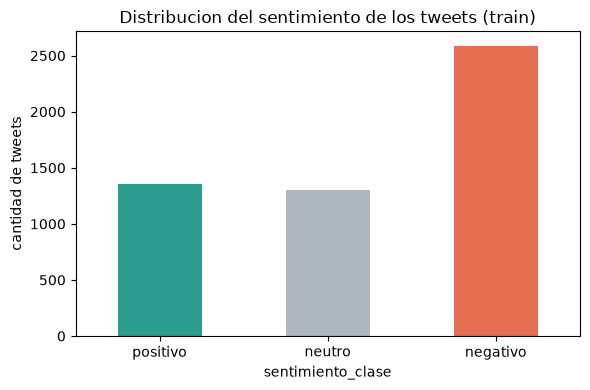

sentimiento_clase
negativo    2587
positivo    1353
neutro      1299 

sentimiento_clase
negativo    49.4%
positivo    25.8%
neutro      24.8%


In [5]:
conteo_clase = train["sentimiento_clase"].value_counts()
conteo_clase_pct = (conteo_clase / len(train) * 100).round(1)

fig, ax = plt.subplots(figsize=(6, 4))
colores = {"positivo": "#2a9d8f", "negativo": "#e76f51", "neutro": "#adb5bd"}
conteo_clase.reindex(["positivo", "neutro", "negativo"]).plot(
    kind="bar", ax=ax, color=[colores[c] for c in ["positivo", "neutro", "negativo"]])
ax.set_title("Distribucion del sentimiento de los tweets (train)")
ax.set_ylabel("cantidad de tweets")
ax.set_xticklabels(["positivo", "neutro", "negativo"], rotation=0)
plt.tight_layout()
plt.show()

print(conteo_clase.to_string(), "\n")
print((conteo_clase_pct.astype(str) + "%").to_string())

**Ejercicio 8 — conclusión.** La mayoría de los tweets del dataset se clasifica como negativo,
lo cual tiene sentido dado el tema del corpus (desastres reales y su uso figurado): incluso los
tweets que no hablan de un desastre real muchas veces usan palabras cargadas negativamente ("fire",
"crash", "wreck" en sentido coloquial).

## **Ejercicio 9 — Tweets más negativos y más positivos**

### **9.1 Los 10 tweets más negativos**

In [6]:
mas_negativos = train.sort_values("sentimiento_compound").head(10)[
    ["text", "sentimiento_compound", "negatividad", "target"]].reset_index(drop=True)
mas_negativos

,text,sentimiento_compound,negatividad,target
0,Suicide bomber kills 15 in Saudi security site...,-0.9623,0.522,1
1,? 19th Day Since 17-Jul-2015 -- Nigeria: Suici...,-0.9595,0.565,1
2,17 killed in S'Arabia mosque suicide bombing\n...,-0.9552,0.559,1
3,at the lake \n*sees a dead fish*\nme: poor lit...,-0.9549,0.507,0
4,@cspan #Prez. Mr. President you are the bigges...,-0.9493,0.496,1
5,Bomb head? Explosive decisions dat produced mo...,-0.9476,0.477,1
6,Udhampur terror attack: Militants attack polic...,-0.9451,0.632,1
7,Udhampur terror attack: Militants attack polic...,-0.9451,0.632,1
8,Photos: 17 people killed and over 25 injured i...,-0.9413,0.597,1
9,"Horrible Accident Man Died In Wings Of ""Airpla...",-0.9406,0.551,1


In [7]:
print("categoria (target) de los 10 tweets mas negativos:")
print(mas_negativos["target"].value_counts().to_string())

categoria (target) de los 10 tweets mas negativos:
target
1    9
0    1


### **9.2 Los 10 tweets más positivos**

In [8]:
mas_positivos = train.sort_values("sentimiento_compound", ascending=False).head(10)[
    ["text", "sentimiento_compound", "negatividad", "target"]].reset_index(drop=True)
mas_positivos

,text,sentimiento_compound,negatividad,target
0,Check out 'Want Twister Tickets AND A VIP EXPE...,0.9730,0.000,0
1,@thoutaylorbrown I feel like accidents are jus...,0.9564,0.049,0
2,Today's storm will pass; let tomorrow's light ...,0.9471,0.000,1
3,Maaaaan I love Love Without Tragedy by @rihann...,0.9394,0.000,0
4,I'm not a Drake fan but I enjoy seeing him bod...,0.9345,0.057,0
5,@duchovbutt @Starbuck_Scully @MadMakNY @davidd...,0.9344,0.000,0
6,Super sweet and beautiful :) https://t.co/TUi9...,0.9300,0.000,0
7,#MeditationByMSG 45600 ppl got method of medit...,0.9287,0.000,0
8,Love love love do you remember your first crus...,0.9266,0.074,0
9,@ckosova Read Whirlwind about this subject amo...,0.9260,0.000,1


In [9]:
print("categoria (target) de los 10 tweets mas positivos:")
print(mas_positivos["target"].value_counts().to_string())

categoria (target) de los 10 tweets mas positivos:
target
0    8
1    2


### **9.3 ¿Son los tweets de desastre real más negativos que los otros?**

In [10]:
resumen = train.groupby("target")[["sentimiento_compound", "negatividad"]].mean().round(4)
resumen.index = resumen.index.map({0: "no desastre", 1: "desastre real"})
resumen

,sentimiento_compound,negatividad
target,,
no desastre,-0.0552,0.1400
desastre real,-0.2599,0.1804


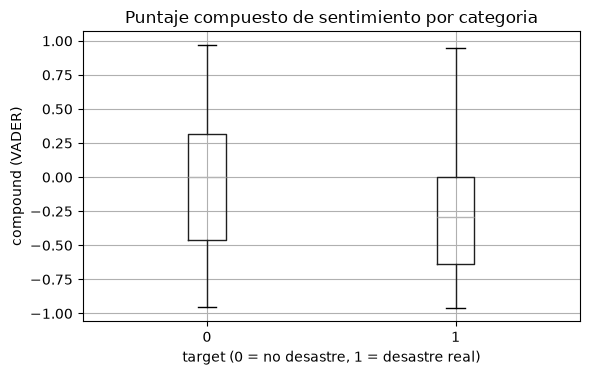

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
train.boxplot(column="sentimiento_compound", by="target", ax=ax)
ax.set_title("Puntaje compuesto de sentimiento por categoria")
ax.set_xlabel("target (0 = no desastre, 1 = desastre real)")
ax.set_ylabel("compound (VADER)")
plt.suptitle("")
plt.tight_layout()
plt.show()

**Ejercicio 9 — discusión.** De los 10 tweets más negativos, 9 pertenecen a la categoría de
desastre real (target = 1) y solo 1 no lo es. De los 10 más positivos ocurre lo contrario: 8 son de
la categoría "no desastre" y 2 sí lo son. Aun así el sentimiento no separa perfectamente las clases,
porque hay tweets de ambas categorías en las dos listas (por eso tiene sentido usarlo como variable
adicional del modelo y no como regla única).

Al comparar los promedios por grupo (tabla de arriba), los tweets de desastre real tienen un
compound promedio de **-0.26** contra **-0.06** de los que no lo son, y una negatividad promedio de
**0.18** contra **0.14**. Es decir que **sí son, en promedio, más negativos**, aunque la diferencia
es moderada y hay bastante traslape entre ambas distribuciones, como se ve en el boxplot.

## **Ejercicio 10 — Variable de negatividad en el modelo**

La variable `negatividad` ya quedó calculada en la etapa 9 del pipeline (componente `neg` de
VADER, en el rango [0, 1]) y está incluida en `train_modelado.csv` y `test_modelado.csv`. Se
reentrena la misma configuración ganadora del ejercicio 6 —**Random Forest, lematización, unigramas,
bolsa de palabras**— agregando `negatividad` como columna extra a la matriz de bolsa de palabras, y
se compara contra el modelo sin esa variable.

In [12]:
def metricas(y_real, y_pred):
    return {"accuracy": accuracy_score(y_real, y_pred), "precision": precision_score(y_real, y_pred),
            "recall": recall_score(y_real, y_pred), "f1": f1_score(y_real, y_pred)}


y_train, y_test = train["target"].values, test["target"].values

vectorizador = CountVectorizer(ngram_range=(1, 1), min_df=2)
X_train_bow = vectorizador.fit_transform(train["tokens"])
X_test_bow = vectorizador.transform(test["tokens"])

modelo_base = RandomForestClassifier(n_estimators=300, min_samples_leaf=2,
                                     n_jobs=-1, random_state=SEMILLA)
modelo_base.fit(X_train_bow, y_train)
m_base = metricas(y_test, modelo_base.predict(X_test_bow))

X_train_neg = hstack([X_train_bow, train[["negatividad"]].values]).tocsr()
X_test_neg = hstack([X_test_bow, test[["negatividad"]].values]).tocsr()

modelo_neg = RandomForestClassifier(n_estimators=300, min_samples_leaf=2,
                                    n_jobs=-1, random_state=SEMILLA)
modelo_neg.fit(X_train_neg, y_train)
m_neg = metricas(y_test, modelo_neg.predict(X_test_neg))

comparacion = pd.DataFrame([{"modelo": "sin negatividad", **m_base},
                            {"modelo": "con negatividad", **m_neg}]).round(4)
comparacion["diferencia_f1"] = (comparacion["f1"] - comparacion.loc[0, "f1"]).round(4)
comparacion

,modelo,accuracy,precision,recall,f1,diferencia_f1
0,sin negatividad,0.8059,0.7984,0.7283,0.7617,0.0000
1,con negatividad,0.7992,0.8100,0.6907,0.7456,-0.0161


**Ejercicio 10 — conclusión.** Se agrega `negatividad` como una columna numérica más a la matriz
dispersa de bolsa de palabras (con `scipy.sparse.hstack`), sin tocar el resto del pipeline de
vectorización, y se reentrena Random Forest con los mismos hiperparámetros del ejercicio 6 para que
la comparación sea limpia.

El resultado (tabla de arriba) es que **la variable no mejoró el modelo**: el f1 bajó de 0.7617 a
0.7456 (-0.0161) y la accuracy bajó de 0.8059 a 0.7992. Sube apenas la precision (0.7984 -> 0.8100),
pero a costa de una caída más fuerte en recall (0.7283 -> 0.6907).

Esto es consistente con lo visto en el ejercicio 9: el sentimiento separa las clases solo de forma
parcial y con bastante traslape entre ambos grupos, así que agregar `negatividad` no le suma
información nueva al modelo, ya que VADER calcula ese puntaje sobre el mismo texto del tweet que ya
ve la bolsa de palabras, y en un bosque de 300 árboles ese único número extra compite en poca
proporción contra miles de columnas de vocabulario, así que su señal se diluye en vez de reforzar la
decisión.